In [2]:
from numpy import pi, log, sqrt 
import getdist
import numpy as np
from io import StringIO
from getdist import plots, MCSamples
import random
from scipy.integrate import quad
from scipy.interpolate import interp1d
from scipy.integrate import odeint
import scipy.integrate as integrate
import matplotlib.pyplot as plt
from scipy import stats
import pypolychord
from pypolychord.settings import PolyChordSettings
from pypolychord.priors import UniformPrior, GaussianPrior
import scipy.optimize as op
from numpy.linalg import inv
from mpi4py import MPI
import sympy as sp
import scipy.linalg as la
import pandas as pd

# Cosmic Chronometers Dataset with Full Covariance

**Source:** [https://gitlab.com/mmoresco/CCcovariance](https://gitlab.com/mmoresco/CCcovariance)

### Description

This analysis utilizes the Cosmic Chronometers (CC) dataset with the full covariance matrix and prepares the likelihood function for cosmological parameter estimation.

### Citation Guidelines

If you use this dataset, please cite the following foundational works by Prof. Dr. Moresco:

- Moresco et al. (2016), [arXiv:1804.05864](https://doi.org/10.48550/arXiv.1804.05864)  
- Moresco (2020), [arXiv:2003.07362](https://doi.org/10.48550/arXiv.2003.07362)  

Additionally, when using the same data, please acknowledge these important references:

- Simon et al. (2005), [arXiv:1201.3609](https://doi.org/10.48550/arXiv.1201.3609)  
- Stern et al. (2010), [arXiv:1503.01116](https://doi.org/10.48550/arXiv.1503.01116)  
- Moresco et al. (2012), [arXiv:1601.01701](https://doi.org/10.48550/arXiv.1601.01701)  

In [3]:
#Load CC dataset and Build Full Covariance Matrix
filename = 'datasets/Hubble_data/HzTable_MM_BC03.dat'
z, Hz, errHz = np.genfromtxt(filename, comments='#', usecols=(0,1,2), unpack=True, delimiter=',')
ref = np.genfromtxt(filename, comments='#', usecols=(3), unpack=True, dtype=str, delimiter=',')

filename = 'datasets/Hubble_data/data_MM20.dat'
zmod, imf, slib, sps, spsooo = np.genfromtxt(filename, comments='#', usecols=(0,1,2,3,4), unpack=True)

cov_mat_diag = np.zeros((len(z), len(z)), dtype='float64')

for i in range(len(z)):
	cov_mat_diag[i,i] = errHz[i]**2

imf_intp = np.interp(z, zmod, imf)/100
slib_intp = np.interp(z, zmod, slib)/100
sps_intp = np.interp(z, zmod, sps)/100
spsooo_intp = np.interp(z, zmod, spsooo)/100

cov_mat_imf = np.zeros((len(z), len(z)), dtype='float64')
cov_mat_slib = np.zeros((len(z), len(z)), dtype='float64')
cov_mat_sps = np.zeros((len(z), len(z)), dtype='float64')
cov_mat_spsooo = np.zeros((len(z), len(z)), dtype='float64')

for i in range(len(z)):
	for j in range(len(z)):
		cov_mat_imf[i,j] = Hz[i] * imf_intp[i] * Hz[j] * imf_intp[j]
		cov_mat_slib[i,j] = Hz[i] * slib_intp[i] * Hz[j] * slib_intp[j]
		cov_mat_sps[i,j] = Hz[i] * sps_intp[i] * Hz[j] * sps_intp[j]
		cov_mat_spsooo[i,j] = Hz[i] * spsooo_intp[i] * Hz[j] * spsooo_intp[j]


cov_mat = cov_mat_spsooo+cov_mat_imf+cov_mat_diag
inv_cov_mat = inv(cov_mat)

cov_mat_cc = inv_cov_mat

# PantheonPlus Dataset (CosmoSIS Likelihood)

**Source Link:** [Pantheon+ CosmoSIS Likelihood Script](https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/5_COSMOLOGY/cosmosis_likelihoods/Pantheon%2B_only_cosmosis_likelihood.py)  
**Dataset Link:** [Pantheon+ Distances and Covariance](https://github.com/PantheonPlusSH0ES/DataRelease/tree/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR)

### Description

This analysis utilizes the full **STAT+SYS** covariance matrix provided in the PantheonPlus data release to construct a supernova likelihood. The approach follows the CosmoSIS likelihood format and incorporates both statistical and systematic uncertainties in the SN Ia light curves.

### Citation Guidelines

If you use this dataset or the associated likelihood script in your research, please cite the following key works:

- **Pantheon+ Compilation and Analysis Methodology:**
  - Brout et al. (2022), [arXiv:2112.03863](https://doi.org/10.48550/arXiv.2112.03863)
  - Scolnic et al. (2022), [arXiv:2202.04077](https://doi.org/10.48550/arXiv.2202.04077)

- **Covariance Matrix Construction:**
  - Conley et al. (2011), [arXiv:1104.1443](https://doi.org/10.48550/arXiv.1104.1443)

In [4]:
#Load Pantheonplus dataset and Build the Covariance Matrix
values_filename = 'datasets/sn_data/PantheonPlus/Pantheon+SH0ES.dat'
cov_filename = 'datasets/sn_data/PantheonPlus/Pantheon+SH0ES_STAT+SYS.cov'

data = pd.read_csv(values_filename, sep=r'\s+')
origlen = len(data)
ww = (data['zHD'] > 0.01)  # Filter condition for zHD > 0.01
zcmb = data['zHD'][ww].values  # vpec corrected redshift (zCMB)
zhelio = data['zHEL'][ww].values  # Heliocentric redshift
mag = data['m_b_corr'][ww].values  # Corrected magnitudes
N = len(mag)

filename = cov_filename
#print("Loading covariance from {}".format(filename))
f = open(filename)
line = f.readline()
n = int(len(zcmb))
C = np.zeros((n,n))
ii = -1
jj = -1
mine = 999
maxe = -999
for i in range(origlen):
    jj = -1
    if ww[i]:
        ii += 1
    for j in range(origlen):
        if ww[j]:
            jj += 1
        val = float(f.readline())
        if ww[i]:
            if ww[j]:
                C[ii,jj] = val

f.close()
#print('Done')
cov = C
xdiag = 1/cov.diagonal()  # diagonal before marginalising constant
zmin = zcmb.min()
zmax = zcmb.max()
zmaxi = 1.1 ## we interpolate to 1.1 beyond that exact calc
print("Pantheon SN: zmin=%f zmax=%f N=%i" % (zmin, zmax, N))
ninterp=150
zinter = np.linspace(1e-3, zmaxi, ninterp)
icov = la.inv(cov)

Pantheon SN: zmin=0.010160 zmax=2.261370 N=1590


# DESI DR2 Dataset with Full Covariance

**Source of Dataset:**  
[DESI BAO Data - GitHub (CobayaSampler)](https://github.com/CobayaSampler/bao_data)

### Description

This analysis utilizes incorporates the **DESI Data Release 2 (DR2)** dataset, which includes baryon acoustic oscillation (BAO) measurements derived from over 14 million galaxies and quasars. The full covariance matrix is used in the likelihood analysis to properly account for measurement uncertainties and correlations between data points.

The dataset is made publicly available and formatted for direct use in cosmological inference frameworks such as [Cobaya](https://cobaya.readthedocs.io/) and [CosmoMC](https://cosmologist.info/cosmomc/).

### Citation Guidelines

If you use this dataset in your work, please cite the following:

- **DESI Collaboration (2025)** : _DESI DR2 Results II: Measurements of Baryon Acoustic Oscillations and Cosmological Constraints_ [arXiv:2503.14738] : (https://doi.org/10.48550/arXiv.2503.14738)

In [5]:
#loading BAO dataset with Covarinace matrix
dirBD= "datasets/DESI_DR2_data/desi_gaussian_bao_ALL_GCcomb_mean.txt"
BaoData = np.genfromtxt(dirBD)
xarr = np.array(BaoData[:,0])
yarr = np.array(BaoData[:,1])

funarr = np.genfromtxt(dirBD,dtype='str')[:,2]
print(funarr)

def modelArr(name):
    mod = []

    for j in range(len(funarr)):
        if (funarr[j] == name):
             mod.append([xarr[j],yarr[j]])
    mod = np.array(mod)
    mod = mod[np.argsort(mod[:,0])]
    return mod

cov_bao = np.loadtxt("datasets/DESI_DR2_data/desi_gaussian_bao_ALL_GCcomb_cov.txt")  
cov_bao_inv = np.linalg.inv(cov_bao)

['DVrd' 'DMrd' 'DHrd' 'DMrd' 'DHrd' 'DMrd' 'DHrd' 'DMrd' 'DHrd' 'DMrd'
 'DHrd' 'DHrd' 'DMrd']


1. **Define the normalized Hubble function** $E(\theta, z)$:

$$
E(z) = \sqrt{\Omega_m (1 + z)^3 + (1 - \Omega_m)}
$$

2. **The Hubble function** $H(\theta, z)$:

$$
H(z) = H_0 \times E(z)
$$


In [6]:
#H functions
c = 299792.458

def E(theta,z):
    H0, Om, w, rd = theta
    return np.sqrt(Om*(1+z)**3 + (1-Om)*((1+z)**(-3*(1+w))))

def H(theta,z):
    H0, Om, w, rd = theta
    arr = []
    for j in range(len(z)):
        arr.append(H0*E(theta,z[j]))
    arr = np.array(arr)
    return arr

H([67,0.30,-1,147],[1,2,3])

array([117.96567297, 198.75411945, 298.88308751])

3. The comoving distance function $D_H(\theta, z)$:

$$
D_H(z) = \frac{c}{H(z)}
$$

4. The comoving distance scaled by the sound horizon:

$$
\frac{D_H(z)}{r_d} = \frac{c}{H(z) \times r_d}
$$


In [7]:
#DH functions
def DH(theta,z):
    H0, Om, w, rd = theta
    arr = []
    for j in range(len(z)):
        arr.append(c/(H0*E(theta,z[j])))
    arr = np.array(arr)
    return arr

def DHrd(theta,z):
    H0, Om, w, rd = theta
    arr = []

    for j in range(len(z)):
        arr.append(c/(H0*E(theta,z[j])*rd))
    arr = np.array(arr)
    return arr

DHrd([67,0.30,-1,147],[1,2,3])

array([17.28811802, 10.26094192,  6.82341879])

The Sk function $S_k(\theta, x)$:

$$
S_k(x) = 
\begin{cases} 
\frac{\sin\left(\sqrt{-\Omega_k} \, x\right)}{\sqrt{-\Omega_k}} & \text{if } \Omega_k < -10^{-15} \\
\frac{\sinh\left(\sqrt{\Omega_k} \, x\right)}{\sqrt{\Omega_k}} & \text{if } \Omega_k > 10^{-15} \\
x & \text{if } \Omega_k = 0
\end{cases}
$$

Where:

* $\Omega_k$ is the curvature parameter (based on the `Ok` variable in your function).
* $x$ is the input variable in the function.

This function evaluates different cases based on the sign and magnitude of $\Omega_k$ (denoted as `Ok`), using either the sine or hyperbolic sine functions, or returning $x$ when $\Omega_k = 0$.


In [8]:
def Sk(theta,x):
    H0, Om, w, rd = theta
    Ok =0
    if Ok < -10**(-15):
        return np.sin(np.sqrt(-Ok)*x)/np.sqrt(-Ok)
    #if Ok == 0:
    #    return x
    elif Ok > 10**(-15):
        return np.sinh(np.sqrt(Ok)*x)/np.sqrt(Ok)
    else:
        return x

**Derivative of $\chi$ with respect to $z$** :

$$
\frac{d\chi}{dz} = \frac{1}{E(\theta, z)}
$$

**Integral of $\chi$** :

$$
\chi(z) = \int_0^z \frac{dz'}{E(\theta, z')}
$$


In [9]:
# function that returns dDC/dz,df/dz
def dchidz(x,z, H0, Om, w, rd):
    return 1/E([H0, Om, w, rd],z)

def chiInt(theta,z):
    H0, Om, w, rd = theta
    z = np.hstack((np.array((0)), z))
    arr = odeint(dchidz,0,z,args=(H0, Om, w, rd,))
    return np.delete(arr ,0)

chiInt([67,0.30,-1,147],[1,2,3])

array([0.77142712, 1.20947123, 1.48401995])

5. The comoving angular diameter distance is computed as: $D_M(\theta, z)$:

$$
D_M(z) = \frac{c}{H_0} \cdot S_k\left( \chi(z) \right)
$$

* $\chi(z) = \int_0^z \frac{c}{H(z')} \, dz'$ is the comoving radial distance
* $S_k(\chi)$ accounts for spatial curvature:

$$
S_k(\chi) =
\begin{cases}
\frac{1}{\sqrt{\Omega_k}} \sinh\left(\sqrt{\Omega_k} \chi\right) & \text{if } \Omega_k > 0 \ (\text{open}) \\
\chi & \text{if } \Omega_k = 0 \ (\text{flat}) \\
\frac{1}{\sqrt{|\Omega_k|}} \sin\left(\sqrt{|\Omega_k|} \chi\right) & \text{if } \Omega_k < 0 \ (\text{closed})
\end{cases}
$$

6. The comoving angular diameter distance scaled by the sound horizon:


$$
\frac{D_M(z)}{r_d} = \frac{c}{H_0 \cdot r_d} \cdot S_k\left( \chi(z) \right)
$$



In [10]:
#DM

def DM(theta,z):
    H0, Om, w, rd = theta
    chi = chiInt(theta,z)

    arr = []

    for i in range(len(z)):
        arr.append(c*Sk(theta,chi[i])/H0)
    arr = np.array(arr)
    arr.shape
    return arr

def DMrd(theta,z):
    H0, Om, w, rd = theta
    chi = chiInt(theta,z)

    arr = []

    for i in range(len(z)):
        arr.append(c*Sk(theta,chi[i])/(H0*rd))
    arr = np.array(arr)
    arr.shape
    return arr

DMrd([67,0.30,-1,147],[1,2,3])

array([23.48137207, 36.81494082, 45.17189442])

7. The volume-averaged distance combines radial and transverse distances and is defined as:

$$
D_V(z) = \left[ z \cdot D_H(z) \cdot D_M(z)^2 \right]^{1/3}
$$

* $D_H(z) = \dfrac{c}{H(z)}$: the comoving Hubble distance
* $D_M(z)$: the comoving angular diameter distance
* This is often used when the BAO measurement is spherically averaged.

8. The volume-averaged diameter distance scaled by the sound horizon:

$$
\frac{D_V(z)}{r_d} = \frac{ \left[ z \cdot D_H(z) \cdot D_M(z)^2 \right]^{1/3} }{r_d}
$$

In [11]:
#DV

def DV(theta,z):
    H0, Om, w, rd = theta
    dh = DH(theta,z)
    dm = DM(theta,z)
    arr = []

    for i in range(len(z)):
        arr.append(np.cbrt(z[i]*dh[i]*dm[i]**2))
    arr = np.array(arr)
    arr.shape
    return arr

def DVrd(theta,z):

    H0, Om, w, rd = theta

    dh = DH(theta,z)
    dm = DM(theta,z)
    arr = []

    for i in range(len(z)):
        arr.append(np.cbrt(z[i]*dh[i]*dm[i]**2)/rd)
    arr = np.array(arr)
    arr.shape
    return arr

DVrd([67,0.30,-1,147],[1,2,3])

array([21.20304425, 30.29854776, 34.69657691])

### Luminosity Distance

$$
D_L(z) = (1 + z) \cdot \frac{c \cdot \chi(z)}{H_0}
$$

### Distance Modulus

$$
\mu(z) = 5 \log_{10} \left( D_L(z) \right) + 25
$$

In [12]:
def DL(theta,z):
    H0, Om, w, rd = theta
    chi = chiInt(theta,z)
    return c*chi/H0

def mu(theta,z):
    H0, Om, w, rd = theta
    dL = DL(theta,z)
    mu = []

    for i in range(len(z)):
        mu.append(5*np.log10(dL[i]*(1+z[i])) + 25)
    mu = np.array(mu)
    mu.shape
    return mu

### Log Likelihood Function for Cosmic Chronometer Measurements

Given a model prediction $H(z; \theta)$, observed data $H_z$, and the inverse covariance matrix $\mathbf{C}^{-1}$, the chi-squared statistic is computed as:

$$
\chi^2 = \left( H(z; \theta) - H_z \right)^T \cdot \mathbf{C}^{-1} \cdot \left( H(z; \theta) - H_z \right)
$$

The corresponding log-likelihood is:

$$
\ln \mathcal{L}(\theta) = -\frac{1}{2} \chi^2
$$


### Output Statistics

The function also returns:

* Minimum chi-squared: $\chi^2_{\text{min}}$
* Total number of data points: $N$
* Reduced chi-squared:

$$
\chi^2_{\text{red}} = \frac{\chi^2}{N - k}
$$

* $p$-value:

$$
p = 1 - F_{\chi^2}(\chi^2; \, \text{dof} = N - k)
$$

* Derived Cosmological Parameters:

$$
\Omega_\Lambda = 1 - \Omega_m \quad (\text{In the case Dark Energy Density })
$$


In [13]:
def lnlike(theta,model,z,Hz,cov_mat_cc):
    prediction = model(theta,z)
    residualcc = prediction - Hz
    chi2 = residualcc.T @ cov_mat_cc @ residualcc
    return chi2

def lnlikeCC(theta):
    chi = 0; i = 0
    chi += lnlike(theta, H, z, Hz, cov_mat_cc)
    i += len(z)
    return -chi, [chi, chi/(i-len(theta)),1-stats.chi2.cdf(x=chi, df=(i-len(theta)))]

print(lnlikeCC([67,0.30,-1,147]))

(np.float64(-6.445570499021103), [np.float64(6.445570499021103), np.float64(0.5859609544564639), np.float64(0.8420438571669299)])


### Log Likelihood Function for BAO Dataset with Full Covariance

Given model predictions $\hat{y}_i = f_i(z_i; \theta)$ (e.g., BAO observables like $D_H$, $D_V$, and $D_A$, etc.), observed data $y_i$, and the inverse covariance matrix $\mathbf{C}^{-1}$, the chi-squared statistic is computed as:

$$
\chi^2(\theta) = \left( \hat{y}(\theta) - y \right)^T \cdot \mathbf{C}^{-1} \cdot \left( \hat{y}(\theta) - y \right)
$$

The corresponding log-likelihood is:

$$
\ln \mathcal{L}(\theta) = -\frac{1}{2} \chi^2(\theta)
$$



In [14]:
# likelihood with covariance matrix
def lnlikecov(theta, model, x, y, cov):
    prediction = []

    for i in range(len(model)):
        fun = model[i]
        prediction.append(eval(fun)(theta, [x[i]]))
    prediction = np.array(prediction)[:, 0]
    vec = (prediction - y)
    result = np.dot(np.dot(vec, cov), vec.T)
    return result

print(lnlikecov([67,0.30,-1,147], funarr, np.array(BaoData[:, 0]), np.array(BaoData[:, 1]), cov_bao_inv))

119.51842954911618


This function computes the log-likelihood of BAO data given cosmological parameters $\theta$. It calculates the chi-squared statistic comparing model predictions to observations using the inverse covariance matrix, then returns the negative chi-squared (log-likelihood), reduced chi-squared, p-value, and the derived parameter $\Omega_\Lambda$, providing a measure of fit quality and model consistency with the data.


In [15]:
def lnlikeBAO(theta):
    x = np.array(BaoData[:, 0])
    y = np.array(BaoData[:, 1])

    # Use your manually loaded inverse covariance matrix
    chi = lnlikecov(theta, funarr, x, y, cov_bao_inv)
    i = len(x)
    return -chi, [chi, chi / (i - len(theta)), 1 - stats.chi2.cdf(x=chi, df=(i - len(theta)))]

lnlikeBAO([67,0.30,-1,147])

(np.float64(-119.51842954911618),
 [np.float64(119.51842954911618),
  np.float64(13.279825505457353),
  np.float64(0.0)])

### Log Likelihood Function for PantheonPlus Dataset with Full Covariance

In this analysis, I marginalize over the nuisance parameter $\mathcal{M}$ (the absolute magnitude offset) using the analytic approach described in Astier et al. (2001) [arXiv:astro-ph/0104009](https://arxiv.org/abs/astro-ph/0104009v1). The method uses the difference

$$
\Delta = 5 \log_{10} \left[d'_L(\theta, z_i)\right] - 5 \log_{10} \left[d'_L(\theta_{\text{true}}, z_i)\right]
\quad \text{(Equation A.8)}
$$

where $d'_L$ is the luminosity distance.

By construction, the minimized chi-squared at the true parameters satisfies

$$
\hat{\chi}^2_{\min} = \hat{\chi}^2(\theta_{\text{true}}) = 0.
$$

Assuming no prior knowledge of $M$, the likelihood is marginalized by integrating the general $\chi^2$ function over $M \in (-\infty, \infty)$:

$$
\tilde{\chi}^2 \equiv \chi^2_{M\text{-int}} = -2 \ln \left[\int_{-\infty}^{\infty} dM \exp\left(-\frac{1}{2} \chi^2 \right)\right]
\quad \text{(Equation A.9)}
$$

This integral can be evaluated analytically to give:

$$
\tilde{\chi}^2 = \hat{\chi}^2 - \frac{B^2}{C} + \ln \left(\frac{C}{2 \pi}\right)
\quad \text{(Equation A.10)}
$$

where

$$
B = \sum_{i=1}^n \frac{\Delta_i}{\sigma_i^2}
\quad \text{(Equation A.11)}
$$

and

$$
C = \sum_{i=1}^n \frac{1}{\sigma_i^2}
\quad \text{(Equation A.12)}
$$

Here, $\sigma_i^2$ are the variances from the covariance matrix.

### Reference

### Citation Guidelines

If you use this liklihood in your work, please cite the following:

- **Astier et al. (2001)** : _Supernovae and the Nature of the Dark Energy_ : [arXiv:astro-ph/0104009](https://arxiv.org/abs/astro-ph/0104009v1)


In [16]:
def A(theta, x, y, icov):
    Mu = mu(theta, x)
    residual = y - Mu 
    chit2 = residual.T @ icov @ residual
    B = np.sum(residual @ icov)
    C = np.sum(icov)
    chi2 = chit2 - (B**2 / C) + np.log(C / (2 * np.pi))
    return chi2

def lnlikePP(theta):
    chi = A(theta, zcmb, mag, icov)
    i = len(zcmb)
    return -chi, [chi, chi/(i-len(theta)),1-stats.chi2.cdf(x=chi, df=(i-len(theta)))]

print(lnlikePP([67,0.30,-1,147]))

(np.float64(-1415.9947331404371), [np.float64(1415.9947331404371), np.float64(0.8928087850822428), np.float64(0.9991010407617408)])


$\mathcal{L}_{\text{CC + BAO + PP}} = \mathcal{L}_{\text{CC}} \times \mathcal{L}_{\text{BAO}} \times \mathcal{L}_{\text{PP}},$

In [17]:
def lnlikeCCBAOPP(theta):

    chi = lnlikecov(theta, funarr, np.array(BaoData[:, 0]), np.array(BaoData[:, 1]), cov_bao_inv)
    i = len(BaoData[:, 0])
    chi += lnlike(theta, H, z, Hz, cov_mat_cc); i += len(z)
    chi += A(theta, zcmb, mag, icov);i += len(zcmb)
    return -chi, [chi, chi/(i-len(theta)), 1 - stats.chi2.cdf(x=chi, df=(i-len(theta)))]

print(lnlikeCCBAOPP([67,0.30,-1,147]))

(np.float64(-1541.9587331885743), [np.float64(1541.9587331885743), np.float64(0.9553647665356718), np.float64(0.8989480678790076)])


In [18]:
runs = 200 # n times 50 (Here n is number of free parameter)

In [19]:
def dumper(live, dead, logweights, logZ, logZerr):
    print("Last dead point:", dead[-1])

In [20]:
def uniprior(hypercube):
    prior = []
    prior.append(UniformPrior(50.,100.)(hypercube[0]))
    prior.append(UniformPrior(0.,1.)(hypercube[1]))
    prior.append(UniformPrior(-3.,1.)(hypercube[2]))
    prior.append(UniformPrior(100.,200.)(hypercube[3]))
    return prior

In [21]:
settingsCCBAOPP = PolyChordSettings(4,3)
settingsCCBAOPP.file_root = 'CC + DESI DR2 + PP'
settingsCCBAOPP.nlive = runs
settingsCCBAOPP.do_clustering = True
settingsCCBAOPP.read_resume = False

In [22]:
outputCCBAOPP = pypolychord.run_polychord(lnlikeCCBAOPP, 4,3, settingsCCBAOPP, uniprior, dumper)

PolyChord: MPI is already initilised, not initialising, and will not finalize

PolyChord: Next Generation Nested Sampling
copyright: Will Handley, Mike Hobson & Anthony Lasenby
  version: 1.22.3
  release: 22nd Nov 2025
    email: wh260@mrao.cam.ac.uk

Run Settings
nlive    :     200
nDims    :       4
nDerived :       3
Doing Clustering
Synchronous parallelisation
Generating equally weighted posteriors
Generating weighted posteriors
Clustering on posteriors
Writing a resume file to chains/CC + DESI DR2 + PP.resume

generating live points


all live points generated

Speed  1 =  0.321E-02 seconds
number of repeats:           20
started sampling

Last dead point: [ 6.21325864e+01  8.28483318e-01 -8.87614046e-01  1.64048786e+02
  9.99286821e+03  6.19136816e+00  0.00000000e+00 -1.00466271e+04
 -9.99286821e+03]
_________________
lives      | 200 |
phantoms   |2498 |
posteriors | 201 |
equals     |   1 |
‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
ncluster   =       1 /       1
ndead      =                 201
npost

In [27]:
paramnames = [('H0','H_{0}'),('Om', r'\Omega_{m0}'),('w', r'\omega'),('rd','r_d (Mpc)'),((r'\chi^2_{min}', r'\chi^2_{min}')),((r'\chi^2_{red}', r'\chi^2_{red}')),('p','p')]
outputCCBAOPP.make_paramnames_files(paramnames)
posteriorCCBAOPP = outputCCBAOPP.posterior

chains/CC + DESI DR2 + PP.txt
Removed no burn in


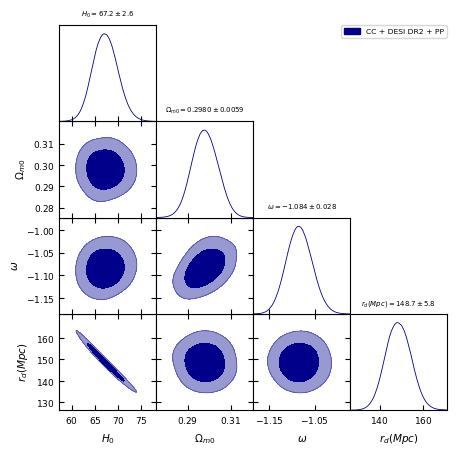

In [28]:
g = getdist.plots.getSubplotPlotter(width_inch=5.0)
g.settings.figure_legend_frame = True  # Remove frame around the legend
g.settings.alpha_filled_add = 0.6  # Adjust transparency of filled contours
g.settings.title_limit_fontsize = 9 # Limit title fontsize to 14
g.settings.axes_labelsize = 12  # Adjust label fontsize
g.settings.legend_fontsize = 10  # Adjust legend fontsize
g.settings.colorbar_axes_fontsize = 10  # Adjust colorbar fontsize
g.triangle_plot([posteriorCCBAOPP], ('H0','Om','w','rd') ,filled=True, contour_colors=['darkblue'], legend_loc='upper right', legend_labels=[r'CC + DESI DR2 + PP'],title_limit=1)
g.export("Plots/wCDM_Posteriors.pdf")

In [29]:
def get_constraints(samples):
    for i, mean in enumerate(samples.getMeans()):
        upper = samples.confidence(i, upper=True, limfrac=0.05)
        #print("\nupper limit 95 C.L. = %f" % upper)
        lower = samples.confidence(i, upper=False, limfrac=0.05)
        #print("lower limit 95 C.L. = %f" % lower)
        print("%s = %f +/- %f +/- %f" % (samples.parLabel(i),\

        mean, mean - samples.confidence(i, limfrac=0.16),\
        mean - samples.confidence(i, limfrac=0.025)) )
    return
for i in ['CCBAOPP']:
    print(i)
    get_constraints(eval("posterior"+i))

CCBAOPP
H_{0} = 67.236611 +/- 2.567197 +/- 4.964816
\Omega_{m0} = 0.297955 +/- 0.005990 +/- 0.011121
\omega = -1.084110 +/- 0.027793 +/- 0.053727
r_d (Mpc) = 148.660174 +/- 5.567269 +/- 11.424951
\chi^2_{min} = 1429.958109 +/- 1.180798 +/- 1.650205
\chi^2_{red} = 0.885972 +/- 0.000732 +/- 0.001022
p = 0.999608 +/- 0.000030 +/- 0.000101


### Here We Compute The Log Of Bayesian Evidence


In [30]:
outputCCBAOPP

Global evidence:
log(Z)    -1442.861961 +/-  0.253706

Local evidences:
log(Z_1)    -1451.974317 +/-  0.700417
log(Z_2)    -1446.550842 +/-  0.269725
log(Z_3)    -1447.160733 +/-  0.286130
log(Z_4)    -1444.700725 +/-  0.256359
log(Z_5)    -1443.082753 +/-  0.253944

Run-time information:
ncluster           5
nposterior      4505
nequals          609
ndead           4505
nlive              0
nlike         394987
<nlike>        [0.0]

Parameter estimates:
H0            H_{0}            6.734E+01 +/- 2.631E+00
Om            \Omega_{m0}      2.977E-01 +/- 5.792E-03
w             \omega          -1.085E+00 +/- 2.664E-02
rd            r_d (Mpc)        1.485E+02 +/- 5.739E+00
\chi^2_{min}  \chi^2_{min}     1.430E+03 +/- 1.301E+00
\chi^2_{red}  \chi^2_{red}     8.859E-01 +/- 8.063E-04
p             p                9.996E-01 +/- 3.796E-05